INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpaenavibe/xcyb34bb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpaenavibe/m4nf0skl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=85019', 'data', 'file=/tmp/tmpaenavibe/xcyb34bb.json', 'init=/tmp/tmpaenavibe/m4nf0skl.json', 'output', 'file=/tmp/tmpaenavibe/prophet_model5xa0zayy/prophet_model-20250401103420.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:34:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:34:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/

| ds                  | yhat    | yhat_lower   | yhat_upper   |
|:--------------------|:--------|:-------------|:-------------|
| 2025-11-30 00:00:00 | 602.426 | 590.889      | 612.576      |
| 2025-12-31 00:00:00 | 602.302 | 591.79       | 613.254      |
| 2026-01-31 00:00:00 | 590.956 | 579.036      | 602.509      |
| 2026-02-28 00:00:00 | 606.107 | 594.069      | 617.78       |
| 2026-03-31 00:00:00 | 616.541 | 602.364      | 629.651      |


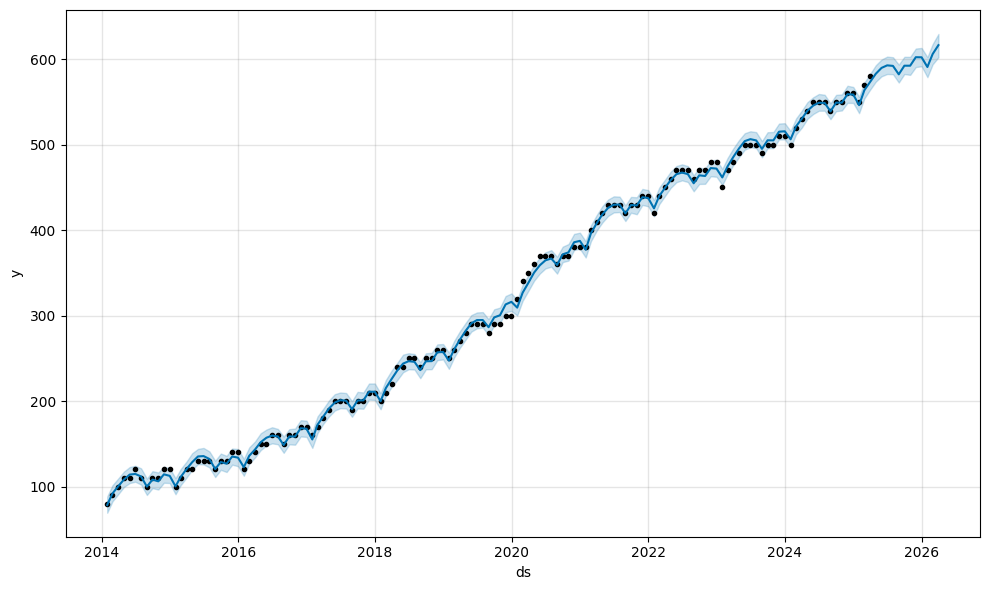

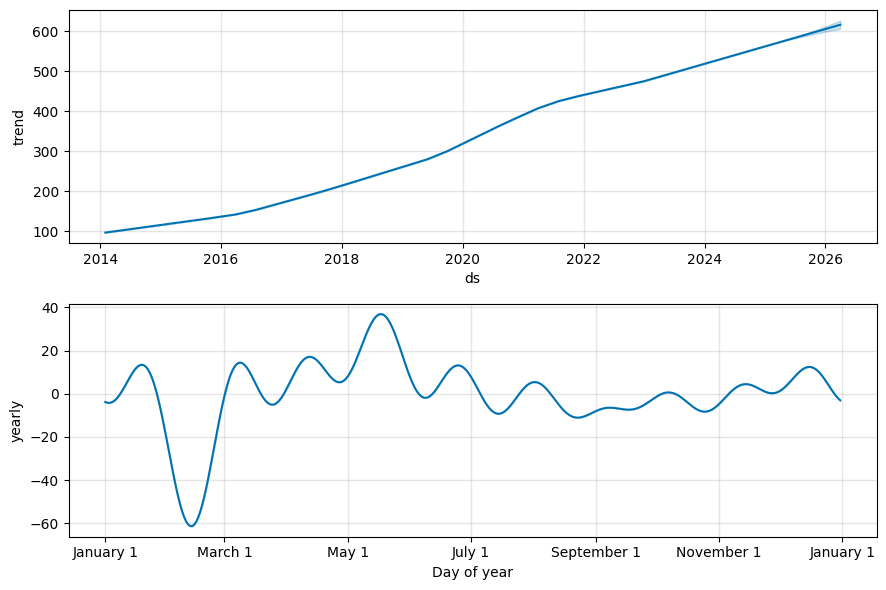

In [ ]:
import pandas as pd
from prophet import Prophet
import altair as alt

# Read the CSV file into a DataFrame
df = pd.read_excel('/content/sale-ecomm.xls')

# Use only 'Date' and 'Sales (billion USD)' columns
df = df[['Date', 'Sales (billion USD)']]

# Rename the columns
df = df.rename(columns={'Date': 'ds', 'Sales (billion USD)': 'y'})

# Convert the column `ds` to datetime, specifying the date format
df['ds'] = pd.to_datetime(df['ds'], format='%d-%m-%Y')

# Instantiate and fit the Prophet model
model = Prophet(interval_width=0.95)
model.fit(df)

# Create a future dataframe for forecasting
future = model.make_future_dataframe(periods=12, freq='M')

# Generate the forecast
forecast = model.predict(future)

# Display the forecast
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail().to_markdown(index=False, numalign="left", stralign="left"))


# הצגת גרף של התחזית
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)
# Create DataFrame for plotting
plot_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].melt('ds', var_name='Metric', value_name='Sales')

# Plot forecast
chart = alt.Chart(plot_df).mark_line(point=True).encode(
    x=alt.X('ds:T', title='Date'),
    y=alt.Y('Sales', title='Sales (billion USD)'),
    color='Metric',
    tooltip=['ds', 'Sales', 'Metric']
).properties(
    title='Sales Forecast'
).interactive()


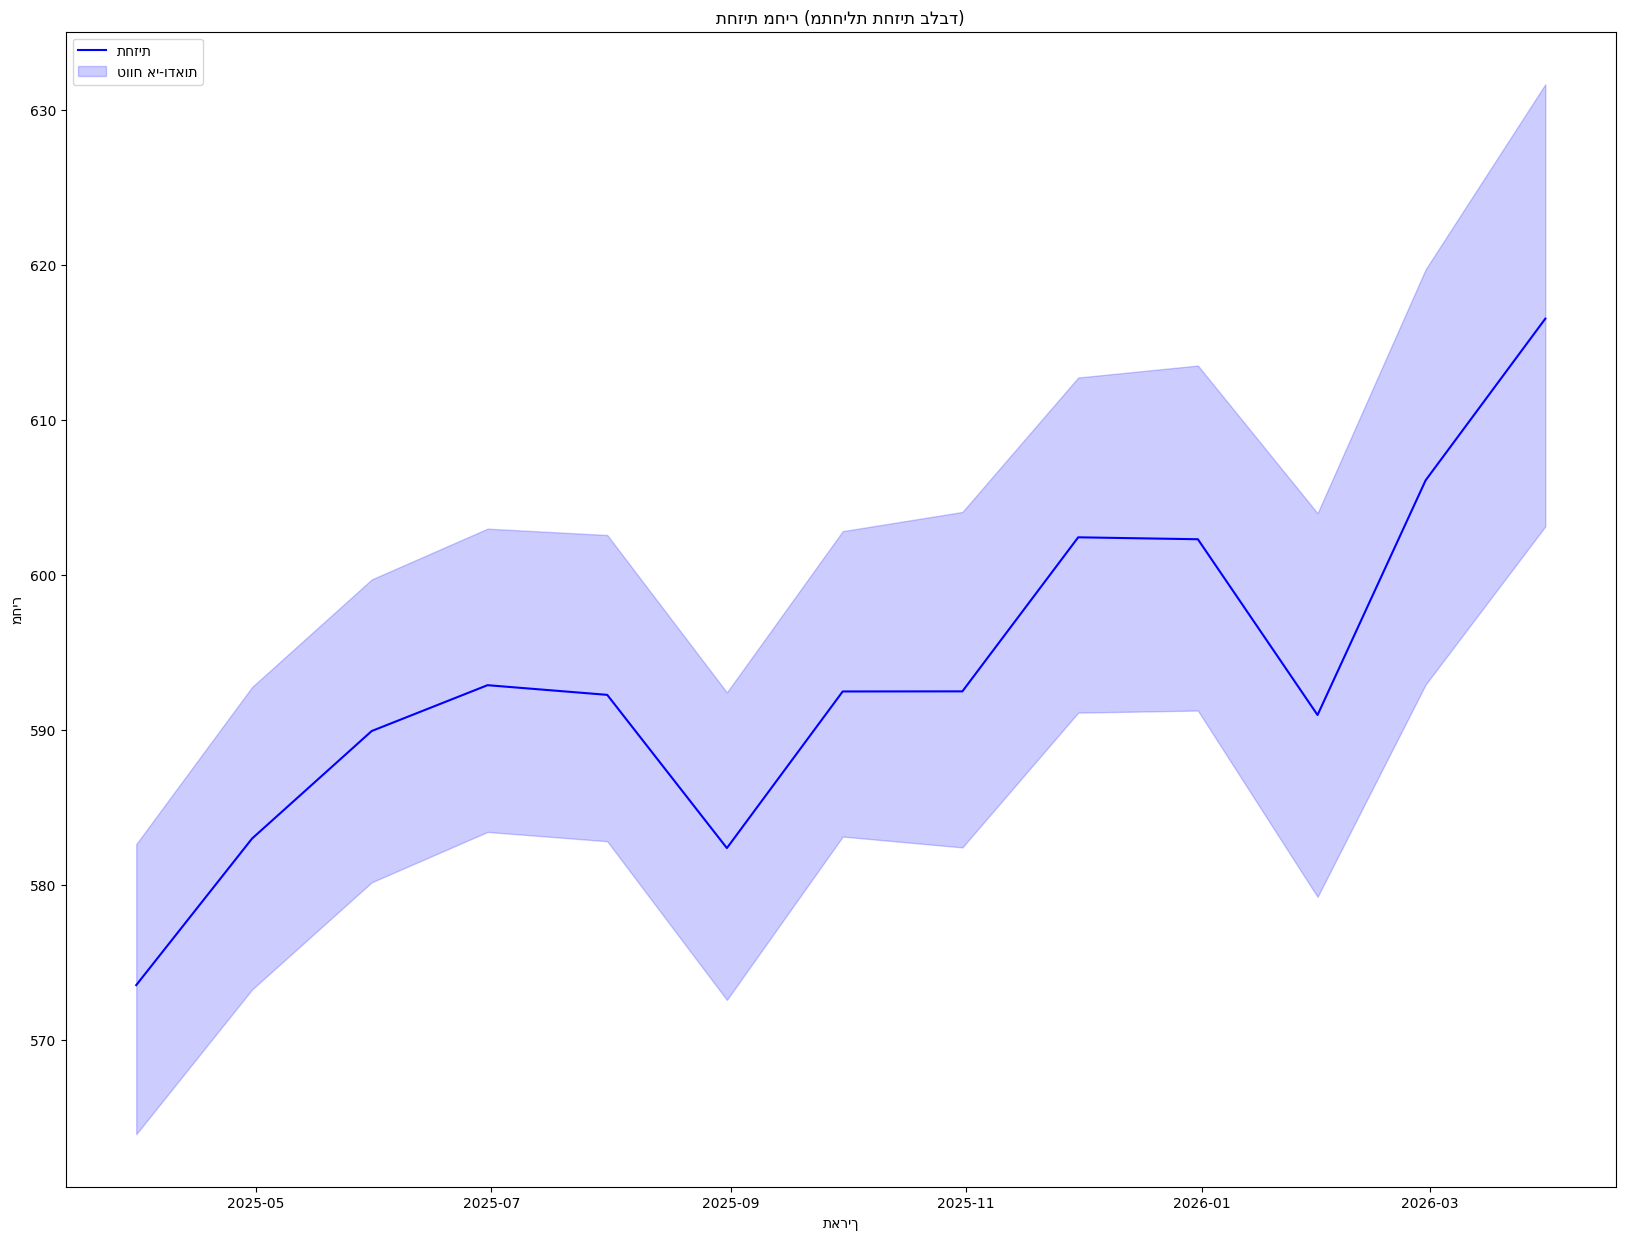

In [ ]:
import matplotlib.pyplot as plt

# סינון נתוני התחזית בלבד (מהתאריך האחרון של הנתונים ההיסטוריים)
forecast_only = forecast[forecast['ds'] >= df['ds'].max()]

# יצירת גרף
plt.figure(figsize=(20, 15))

# נתוני תחזית בלבד
plt.plot(forecast_only['ds'], forecast_only['yhat'], 'b-', label='תחזית')  # קו תחזית
plt.fill_between(forecast_only['ds'], forecast_only['yhat_lower'], forecast_only['yhat_upper'], color='blue', alpha=0.2, label='טווח אי-ודאות')  # תחום אי-ודאות

# הגדרות גרף
plt.xlabel('תאריך')
plt.ylabel('מחיר')
plt.legend()
plt.grid(False)
plt.title('תחזית מחיר (מתחילת תחזית בלבד)')
plt.show()

In [ ]:
# חישוב מדדי ביצועים
from sklearn.metrics import mean_squared_error, r2_score

# Filter forecast to match the length of df
forecast_filtered = forecast[forecast['ds'].isin(df['ds'])]

#Now calculate the metrics using the filtered forecast data
mse = mean_squared_error(df['y'], forecast_filtered['yhat'])
r2 = r2_score(df['y'], forecast_filtered['yhat'])


# הדפסת התוצאות
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")

R² Score: 0.9990
MSE: 23.4490


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpaenavibe/f1a7pw34.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpaenavibe/8maa6vm1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=17254', 'data', 'file=/tmp/tmpaenavibe/f1a7pw34.json', 'init=/tmp/tmpaenavibe/8maa6vm1.json', 'output', 'file=/tmp/tmpaenavibe/prophet_model9z_8dt4h/prophet_model-20250401103429.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:34:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:34:29 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/

| ds                  | yhat    | yhat_lower   | yhat_upper   |
|:--------------------|:--------|:-------------|:-------------|
| 2025-11-30 00:00:00 | 587.658 | 572.256      | 602.733      |
| 2025-12-31 00:00:00 | 586.681 | 570.866      | 602.24       |
| 2026-01-31 00:00:00 | 575.205 | 559.533      | 590.258      |
| 2026-02-28 00:00:00 | 589.304 | 574.477      | 604.754      |
| 2026-03-31 00:00:00 | 597.942 | 582.775      | 612.428      |


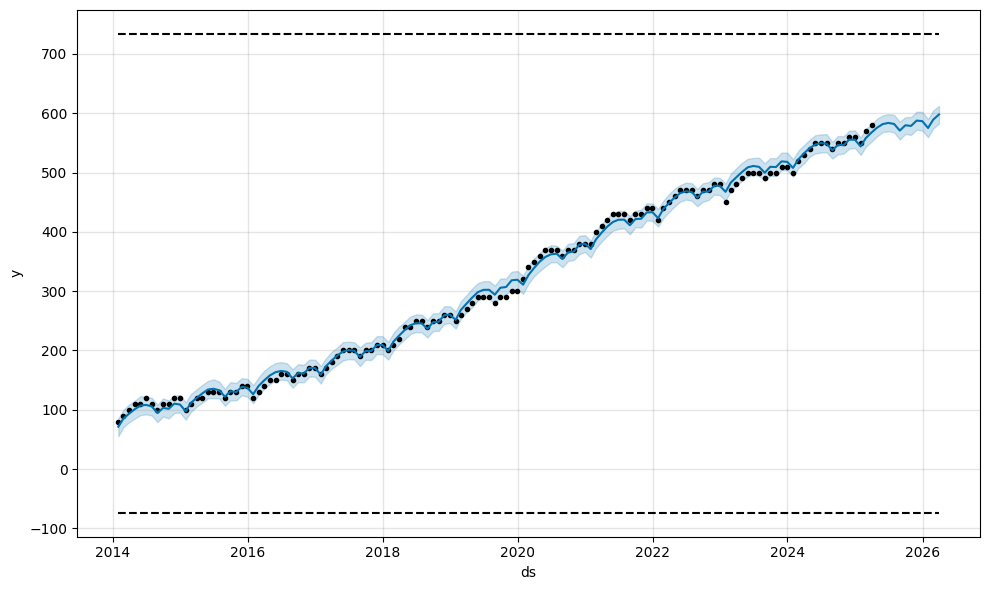

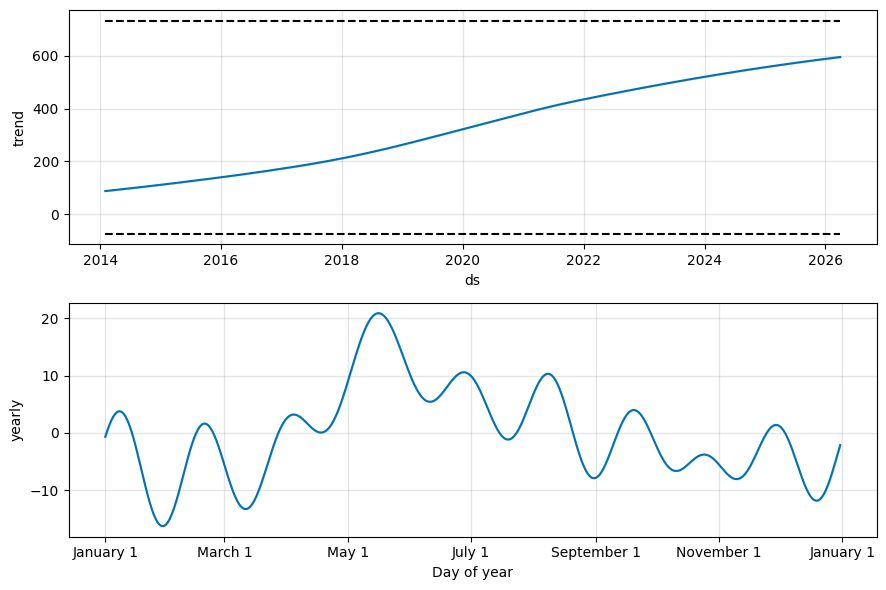

In [ ]:
import pandas as pd
from prophet import Prophet
import altair as alt

# Read the CSV file into a DataFrame
df = pd.read_excel('/content/sale-ecomm.xls')

# Use only 'Date' and 'Sales (billion USD)' columns
df = df[['Date', 'Sales (billion USD)']]

# Rename the columns
df = df.rename(columns={'Date': 'ds', 'Sales (billion USD)': 'y'})

# Convert the column `ds` to datetime, specifying the date format
df['ds'] = pd.to_datetime(df['ds'], format='%d-%m-%Y')
stdev = df['y'].std()
# Calculate cap and floor dynamically
cap = df['y'].max() + (1 * stdev)  # Cap: Max + 2 stdevs
floor = df['y'].min() - (1 * stdev)  # Floor: Min - 2 stdevs
#For Floor =0
#floor = 0
# Add cap and floor to DataFrame
df['cap'] = cap
df['floor'] = floor

# Instantiate and fit the Prophet model
model = Prophet(growth='logistic',interval_width=0.95)
model.fit(df)

# Create a future dataframe for forecasting
future = model.make_future_dataframe(periods=12, freq='M')
#Adding cap and floor to future dataframe

future['cap'] = cap
future['floor'] = floor
# Generate the forecast
forecast = model.predict(future)

# Display the forecast
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail().to_markdown(index=False, numalign="left", stralign="left"))


# הצגת גרף של התחזית
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)
# Create DataFrame for plotting
plot_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].melt('ds', var_name='Metric', value_name='Sales')

# Plot forecast
chart = alt.Chart(plot_df).mark_line(point=True).encode(
    x=alt.X('ds:T', title='Date'),
    y=alt.Y('Sales', title='Sales (billion USD)'),
    color='Metric',
    tooltip=['ds', 'Sales', 'Metric']
).properties(
    title='Sales Forecast'
).interactive()


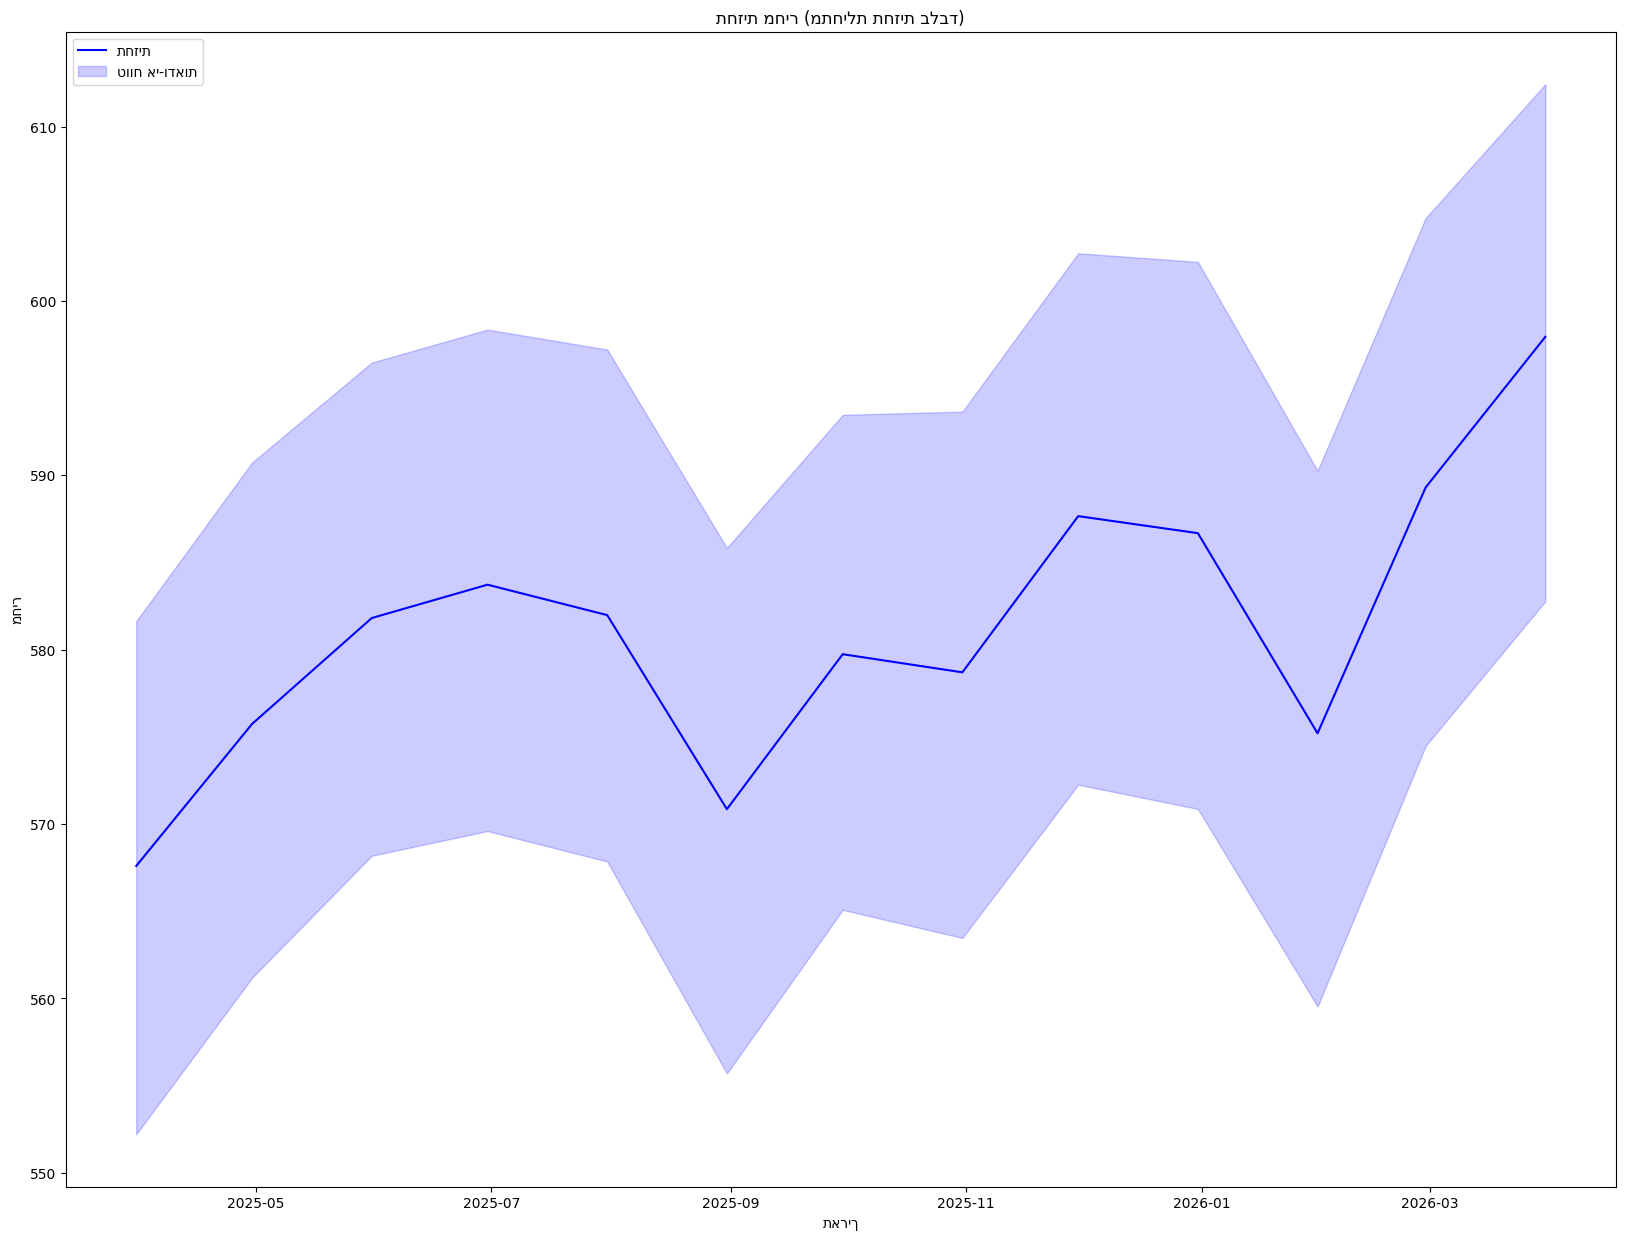

In [ ]:
import matplotlib.pyplot as plt

# סינון נתוני התחזית בלבד (מהתאריך האחרון של הנתונים ההיסטוריים)
forecast_only = forecast[forecast['ds'] >= df['ds'].max()]

# יצירת גרף
plt.figure(figsize=(20, 15))

# נתוני תחזית בלבד
plt.plot(forecast_only['ds'], forecast_only['yhat'], 'b-', label='תחזית')  # קו תחזית
plt.fill_between(forecast_only['ds'], forecast_only['yhat_lower'], forecast_only['yhat_upper'], color='blue', alpha=0.2, label='טווח אי-ודאות')  # תחום אי-ודאות

# הגדרות גרף
plt.xlabel('תאריך')
plt.ylabel('מחיר')
plt.legend()
plt.grid(False)
plt.title('תחזית מחיר (מתחילת תחזית בלבד)')
plt.show()

In [ ]:
# חישוב מדדי ביצועים
from sklearn.metrics import mean_squared_error, r2_score

# Filter forecast to match the length of df
forecast_filtered = forecast[forecast['ds'].isin(df['ds'])]

#Now calculate the metrics using the filtered forecast data
mse = mean_squared_error(df['y'], forecast_filtered['yhat'])
r2 = r2_score(df['y'], forecast_filtered['yhat'])


# הדפסת התוצאות
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")

R² Score: 0.9976
MSE: 56.5430
